<h1 align="center">Descriptive Analysis</h1>

In [32]:
# 1. Data Manipulation
import pandas as pd
import numpy as np

# 2. Visualization
import matplotlib.pyplot as plt


# Settings to make the analysis look better
%matplotlib inline

In [33]:
# Reading the cleaned csv file
df = pd.read_csv("Data/cleaned/Team01_PYVoyagers_cleaned_data.csv")
demo = pd.read_csv("Data/cleaned/Cleaned_demographics.csv")

In [34]:
df.head(5)

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id,age,gender,race,average_sleep_duration_hrs,sleep_quality_1_10,_with_sleep_disturbances
0,2018-06-13 18:40:00,282.9995,6.360,82.323,27.5,0.092,0.0,0.0,HUPA0001P,34,Male,Other,6.3,4.5,80
1,2018-06-13 18:45:00,282.9995,7.728,83.740,0.0,0.092,0.0,0.0,HUPA0001P,34,Male,Other,6.3,4.5,80
2,2018-06-13 18:50:00,282.9995,4.750,80.525,0.0,0.092,0.0,0.0,HUPA0001P,34,Male,Other,6.3,4.5,80
3,2018-06-13 18:55:00,282.9995,6.359,89.129,20.0,0.092,0.0,0.0,HUPA0001P,34,Male,Other,6.3,4.5,80
4,2018-06-13 19:00:00,282.9995,5.152,92.496,0.0,0.075,0.0,0.0,HUPA0001P,34,Male,Other,6.3,4.5,80


## 1. Average glucose, heart rate and steps by Gender and Age
When we look at glucose + heart rate + steps together, we can identify patterns like:

High glucose + low steps indicates sedentary lifestyle driving metabolic risk

High heart rate + low steps → poor cardiovascular fitness

Normal glucose but low steps → early lifestyle risk before metabolic markers worsen

High glucose + high heart rate → possible autonomic dysfunction or chronic stress

This is the foundation of risk stratification in population health.


In [35]:
summary_by_gender_age = (
    df.groupby(['gender', 'age'])
    .agg({
        'glucose': 'mean',
        'heart_rate': 'mean',
        'steps': 'sum'
    })
    .round(3)
    .reset_index()
)

print(summary_by_gender_age)


    gender  age  glucose  heart_rate     steps
0   Female   20  142.639      78.227   35895.5
1   Female   30  137.325      75.038   21074.5
2   Female   33  161.836      68.253   34845.0
3   Female   34  175.467      78.052   28651.0
4   Female   60  130.684      76.581  864694.5
5   Female   63  158.232      73.788   46127.0
6   Female   64  197.633      81.944   31043.0
7   Female   65  193.530      84.606   38225.5
8   Female   74  133.025      67.943   17720.0
9     Male   22  134.791      78.102   33182.0
10    Male   29  188.041      77.470   25683.0
11    Male   33  161.528      80.276  421078.0
12    Male   34  176.551      80.773   24980.5
13    Male   35  129.645      63.739   39401.5
14    Male   44  113.846      78.761   31419.5
15    Male   46  154.526      80.848   70198.5
16    Male   49  131.916      76.446   43325.5
17    Male   53  165.657      73.793   37679.5
18    Male   56  184.432      82.567   26353.5
19    Male   62  128.435      75.529  123438.0
20    Male   

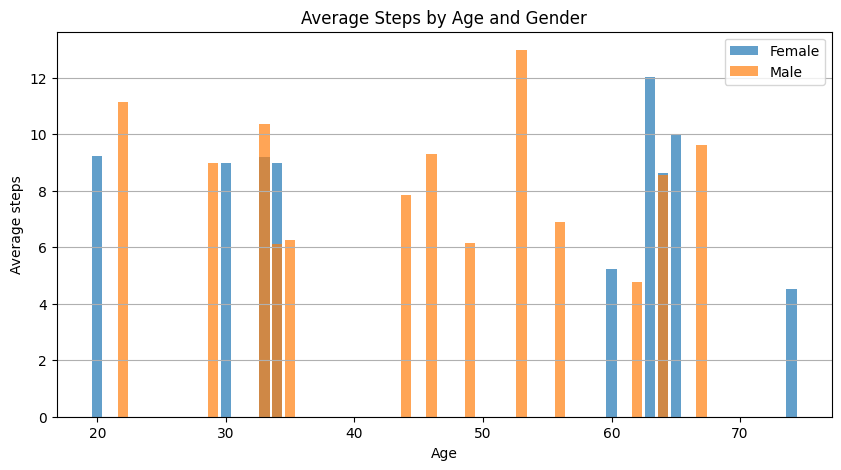

In [36]:
steps_summary = (
    df.groupby(['gender', 'age'])['steps']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

for gender in steps_summary['gender'].unique():
    data = steps_summary[steps_summary['gender'] == gender]
    plt.bar(data['age'], data['steps'], alpha=0.7, label=gender)

plt.title('Average Steps by Age and Gender')
plt.xlabel('Age')
plt.ylabel('Average steps')
plt.legend()
plt.grid(axis='y')
plt.show()


In [37]:
#We can see that male patients show significantly higher average steps compared to female patients as age increases.

## 2. How long does it take for patients to return to normal Glucose levels after a Glucose spike?
Most healthy individuals return to normal glucose levels within 2–3 hours after a spike.
This reflects good insulin sensitivity and efficient glucose clearance.

Patients with insulin resistance, prediabetes, or diabetes may take 4–6 hours or longer to return to baseline.
A slower return indicates impaired insulin action, reduced metabolic flexibility, and higher cardiometabolic risk.

This metric helps identify early metabolic dysfunction and supports risk stratification in population health.

In [38]:
import pandas as pd

HIGH_GLUCOSE = 180
NORMAL_MIN = 70
NORMAL_MAX = 180

results = []
df['time'] = pd.to_datetime(df['time'])

for patient_id, patient_df in df.groupby('patient_id'):
    patient_df = patient_df.sort_values('time').reset_index(drop=True)

    in_spike = False
    spike_start_time = None
    spike_start_glucose = None

    for i, row in patient_df.iterrows():
        glucose = row['glucose']
        time = row['time']
 # Comparing Glucose with range
        if not in_spike and glucose > HIGH_GLUCOSE:
            in_spike = True
            spike_start_time = time
            spike_start_glucose = glucose

        elif in_spike and NORMAL_MIN <= glucose <= NORMAL_MAX:
            # converting time to hours
            hours_to_normal = (time - spike_start_time).total_seconds() / 60/60

            results.append({
                'patient_id': patient_id,
                'spike_start_time': spike_start_time,
                'spike_start_glucose': spike_start_glucose,
                'return_to_normal_time': time,
                'return_to_normal_glucose': glucose,
                'hours_to_return_normal': hours_to_normal
            })

            in_spike = False

glucose_recovery = pd.DataFrame(results)

print(glucose_recovery.head())


  patient_id    spike_start_time  spike_start_glucose return_to_normal_time  \
0  HUPA0001P 2018-06-13 18:40:00             282.9995   2018-06-13 20:00:00   
1  HUPA0001P 2018-06-13 20:05:00             205.0000   2018-06-13 20:15:00   
2  HUPA0001P 2018-06-13 22:35:00             184.0000   2018-06-13 22:45:00   
3  HUPA0001P 2018-06-14 00:55:00             182.0000   2018-06-14 01:00:00   
4  HUPA0001P 2018-06-14 01:05:00             182.0000   2018-06-14 01:15:00   

   return_to_normal_glucose  hours_to_return_normal  
0                     171.0                1.333333  
1                     135.0                0.166667  
2                     150.0                0.166667  
3                     134.0                0.083333  
4                     140.0                0.166667  


avg_recovery_by_patient = (
    glucose_recovery
    .groupby('patient_id')['hours_to_return_normal']
    .mean()
    .round(2)
    .reset_index()
    .rename(columns={
        'Patient_ID': 'Patient ID',
        'hours_to_return_normal': 'Average Hours to Return to Normal'
    })
)

display(avg_recovery_by_patient)


## 1 How heart rate differs between active vs sedentary users.
Here we compared heart rate during active versus sedentary periods.
 Active intervals—defined by any steps recorded—showed a noticeably higher average heart rate,
reflecting increased cardiovascular demand.
Sedentary intervals stayed closer to resting levels
Active users → higher HR (movement increases cardiovascular demand)
Sedentary users → lower HR (resting or low‑movement state)

In [39]:
cols_to_round = ['steps', 'calories', 'heart_rate']
df[cols_to_round] = df[cols_to_round].round(3)


# 1. Create Activity Category
df['activity_level'] = df['steps'].apply(lambda x: 'Active' if x > 0 else 'Sedentary')

# 2. Compare Heart Rate 
hr_summary = (
    df.groupby('activity_level')['heart_rate']
      .agg(
          avg_hr='mean',
          median_hr='median',
          max_hr='max',
          min_hr='min',
          count='count'
      )
      .round(3)
      .reset_index()
)

print("\nHeart Rate Summary: Active vs Sedentary\n")
print(hr_summary)



Heart Rate Summary: Active vs Sedentary

  activity_level  avg_hr  median_hr   max_hr  min_hr   count
0         Active  88.179     86.957  116.638  46.107   90042
1      Sedentary  72.196     70.512  116.638  33.906  219350


## 2. What is the profile of users with high glucose(steps, calories, HR)
We profiled Paitents with high glucose levels by comparing their steps, calories, and heart rate patterns.
High‑glucose Patients consistently showed lower daily steps,higher calorie intake, and elevated heart rates, suggesting reduced activity and higher metabolic load.

In [40]:
df['high_glucose_flag'] = df['glucose'] > 180
# 4. Per‑Patient High Glucose Profile

user_profile = (
    df.groupby(['patient_id','high_glucose_flag'])[['steps','calories','heart_rate']]
    .mean()
    .round(3)
)

print("\n=== Per Patient High Glucose Profile \n")
print(user_profile)





=== Per Patient High Glucose Profile 

                               steps  calories  heart_rate
patient_id high_glucose_flag                              
HUPA0001P  False               5.073     5.489      78.456
           True                7.512     6.141      83.965
HUPA0002P  False               8.084     8.531      66.181
           True                9.571     9.139      69.746
HUPA0003P  False               9.577     8.806      79.241
           True                5.606     7.455      74.445
HUPA0004P  False               7.334     8.797      76.130
           True               10.993    10.026      80.356
HUPA0005P  False               4.150     5.365      84.444
           True                5.081     5.702      84.585
HUPA0006P  False               6.455     7.962      64.200
           True                9.462     9.015      68.005
HUPA0007P  False               8.935     9.961      69.787
           True               10.461    10.351      70.419
HUPA0009P  False

## 3. Glucose distribution by HR zone

**Absolute bpm zones** (clinically intuitive, comparable across studies):
- Resting: `< 80 bpm`
- Moderate: `80 – 110 bpm`
- High: `≥ 110 bpm`

**Age-adjusted %HRmax zones** (fairer across ages because HR-max declines ~1 bpm/year). Using the standard formula `HRmax = 220 − age`:
- Resting/Light: `< 50 %HRmax`
- Moderate: `50 – 70 %HRmax`
- High: `≥ 70 %HRmax`

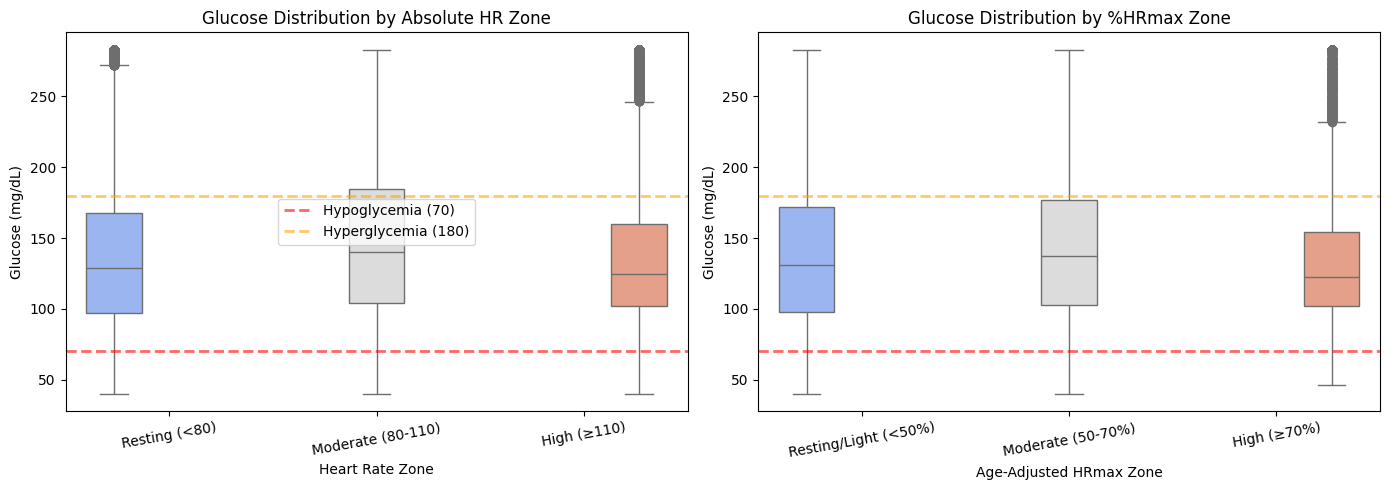

In [41]:
import seaborn as sns
HYPO = 70
HYPER = 180
TIR_RANGE = (70, 180)
df['hr_zone_bpm'] = pd.cut(df['heart_rate'],
                            bins=[0, 80, 110, 300],
                            labels=['Resting (<80)', 'Moderate (80-110)', 'High (≥110)'])

df['hr_max']     = 220 - df['age']
df['hr_pct_max'] = df['heart_rate'] / df['hr_max'] * 100
df['hr_zone_pct'] = pd.cut(df['hr_pct_max'],
                            bins=[0, 50, 70, 200],
                            labels=['Resting/Light (<50%)', 'Moderate (50-70%)', 'High (≥70%)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =========================================================
# BOXPLOT 1: Glucose vs Absolute Heart Rate Zones
# =========================================================
sns.boxplot(
    data=df.dropna(subset=['hr_zone_bpm']),
    x='hr_zone_bpm',
    y='glucose',
    ax=axes[0],
    order=[
        'Resting (<80)',
        'Moderate (80-110)',
        'High (≥110)'
    ],
    hue='hr_zone_bpm',      # avoids seaborn future warning
    palette='coolwarm',
    legend=False
)

# Clinical threshold lines
axes[0].axhline(
    HYPO,
    color='red',
    linestyle='--',
    alpha=0.6,
    linewidth=2,
    label='Hypoglycemia (70)'
)

axes[0].axhline(
    HYPER,
    color='orange',
    linestyle='--',
    alpha=0.6,
    linewidth=2,
    label='Hyperglycemia (180)'
)

axes[0].set_title(
    'Glucose Distribution by Absolute HR Zone',
    fontsize=12
)

axes[0].set_xlabel('Heart Rate Zone')
axes[0].set_ylabel('Glucose (mg/dL)')
axes[0].tick_params(axis='x', rotation=10)
axes[0].legend()


# =========================================================
# BOXPLOT 2: Glucose vs Age-Adjusted HRmax %
# =========================================================
sns.boxplot(
    data=df.dropna(subset=['hr_zone_pct']),
    x='hr_zone_pct',
    y='glucose',
    ax=axes[1],
    order=[
        'Resting/Light (<50%)',
        'Moderate (50-70%)',
        'High (≥70%)'
    ],
    hue='hr_zone_pct',
    palette='coolwarm',
    legend=False
)

# Clinical threshold lines
axes[1].axhline(
    HYPO,
    color='red',
    linestyle='--',
    alpha=0.6,
    linewidth=2
)

axes[1].axhline(
    HYPER,
    color='orange',
    linestyle='--',
    alpha=0.6,
    linewidth=2
)

axes[1].set_title(
    'Glucose Distribution by %HRmax Zone',
    fontsize=12
)

axes[1].set_xlabel('Age-Adjusted HRmax Zone')
axes[1].set_ylabel('Glucose (mg/dL)')
axes[1].tick_params(axis='x', rotation=10)

# =========================================================
# FINAL LAYOUT
# =========================================================
plt.tight_layout()
plt.show()

## 4. Average Glucose by Patient
**Column Summary:**
- `mean` / `median` — central tendency, the headline answer to the question.
- `std` — dispersion; two patients with the same mean glucose can have very different variability and risk profiles.
- `tir` (Time-In-Range 70–180) — the standard clinical target (>70%); a single number that aligns with diabetes guidelines.
- `tbr` / `tar` — Time-Below-Range and Time-Above-Range break the tail risks apart; tbr is the more dangerous one acutely.


PATIENT-LEVEL GLUCOSE SUMMARY TABLE

              mean    std  median    tir    tbr    tar  age  gender  \
patient_id                                                            
HUPA0017P   197.63  64.36  207.00  35.70   2.39  61.91   64  Female   
HUPA0009P   193.53  45.67  192.00  41.45   0.00  58.55   65  Female   
HUPA0020P   188.04  68.53  185.17  44.76   3.56  51.68   29    Male   
HUPA0014P   184.43  65.64  184.00  44.06   4.05  51.89   56    Male   
HUPA0001P   176.55  60.10  165.67  56.49   1.44  42.07   34    Male   
HUPA0004P   175.47  74.34  171.67  44.82   9.70  45.48   34  Female   
HUPA0007P   169.89  72.68  170.33  45.86   8.94  45.19   67    Male   
HUPA0024P   165.66  63.74  171.00  48.38   7.79  43.83   53    Male   
HUPA0015P   161.84  64.42  150.33  58.68   4.17  37.16   33  Female   
HUPA0019P   161.56  57.22  157.00  62.38   2.69  34.92   46    Male   
HUPA0026P   161.53  65.33  157.33  53.54   7.71  38.75   33    Male   
HUPA0006P   159.68  73.69  146.00  56.0

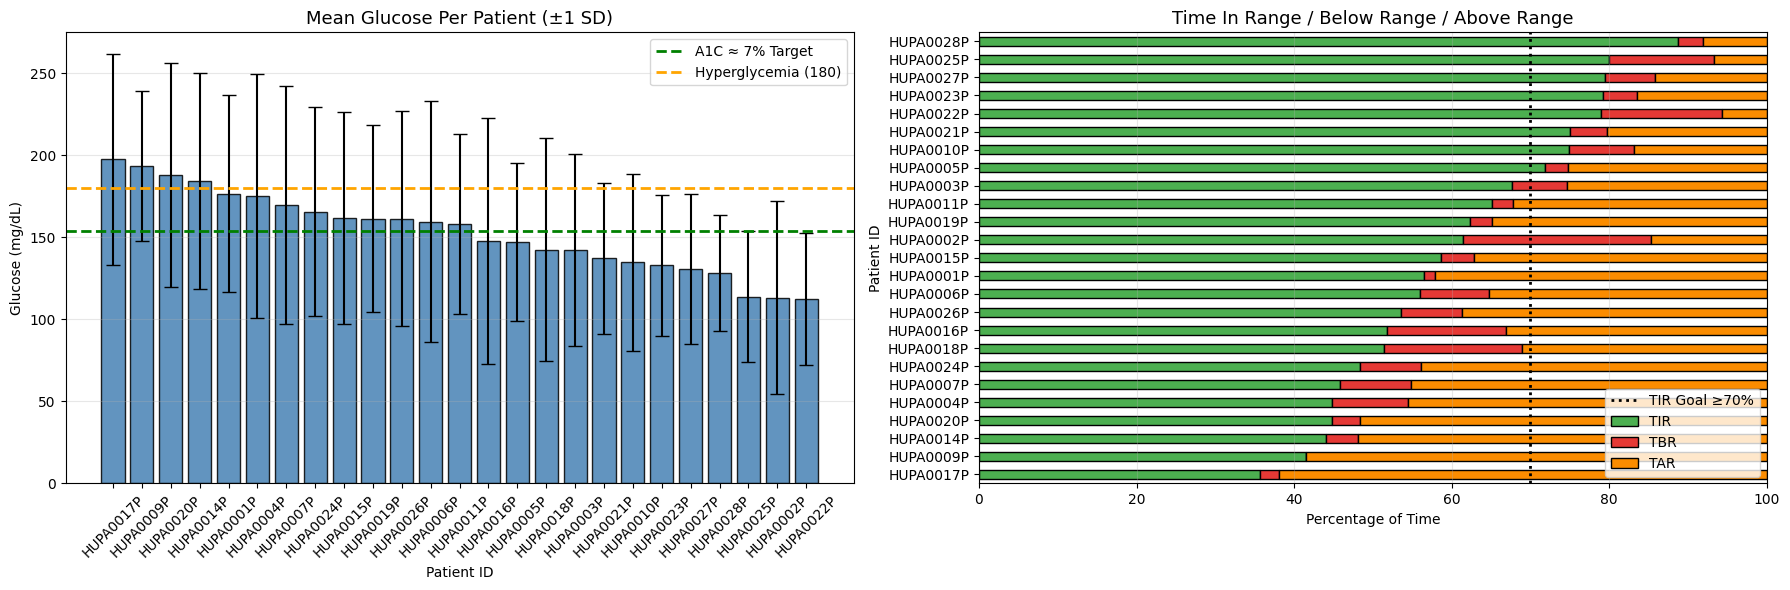

In [42]:
# =========================================================
# PATIENT-LEVEL GLUCOSE SUMMARY METRICS
# =========================================================
import numpy as np
import pandas as pd
# =========================================================
# CLINICAL THRESHOLDS (mg/dL)
# =========================================================
HYPO = 70
HYPER = 180
# =========================================================
# PATIENT-LEVEL AGGREGATION
# =========================================================
per_pt = (
    df.groupby('patient_id')['glucose']
      .agg([
          'mean',
          'std',
          'median',
          # Time in Range (TIR: 70–180 mg/dL)
          (
              'tir',
              lambda x: (
                  ((x >= HYPO) & (x <= HYPER)).mean() * 100
              )
          ),
          # Time Below Range (TBR: <70 mg/dL)
          (
              'tbr',
              lambda x: (
                  (x < HYPO).mean() * 100
              )
          ),
          # Time Above Range (TAR: >180 mg/dL)
          (
              'tar',
              lambda x: (
                  (x > HYPER).mean() * 100
              )
          ),
          # Number of readings per patient
          ('n', 'size')
      ])
      .round(2)
)
# =========================================================
# MERGE WITH DEMOGRAPHICS
# =========================================================

per_pt = (
    per_pt.merge(
        demo[
            [
                'patient_id',
                'age',
                'gender',
                'average_sleep_duration_hrs',
                'sleep_quality_1_10'
            ]
        ],
        left_index=True,
        right_on='patient_id'
    )
    .set_index('patient_id')
)
# =========================================================
# SORT BY MEAN GLUCOSE (RISK INDICATOR)
# =========================================================
per_pt = per_pt.sort_values('mean', ascending=False)
# =========================================================
# FINAL OUTPUT TABLE
# =========================================================
cols_to_show = [
    'mean',
    'std',
    'median',
    'tir',
    'tbr',
    'tar',
    'age',
    'gender',
    'average_sleep_duration_hrs',
    'sleep_quality_1_10'
]
print("\n=================================================")
print("PATIENT-LEVEL GLUCOSE SUMMARY TABLE")
print("=================================================\n")
print(per_pt[cols_to_show])
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
# =========================================================
# CHART 1: Mean Glucose Per Patient
# =========================================================
axes[0].bar(
    per_pt.index.astype(str),
    per_pt['mean'],
    yerr=per_pt['std'],
    capsize=5,
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)
# Clinical reference lines
axes[0].axhline(
    154,
    color='green',
    linestyle='--',
    linewidth=2,
    label='A1C ≈ 7% Target'
)
axes[0].axhline(
    HYPER,
    color='orange',
    linestyle='--',
    linewidth=2,
    label='Hyperglycemia (180)'
)
axes[0].set_title(
    'Mean Glucose Per Patient (±1 SD)',
    fontsize=13
)
axes[0].set_ylabel('Glucose (mg/dL)')
axes[0].set_xlabel('Patient ID')
# Better x-label readability
axes[0].tick_params(axis='x', rotation=45)
# Add light grid
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

# =========================================================
# CHART 2: TIR / TBR / TAR
# =========================================================
tir_sorted = (
    per_pt[['tir', 'tbr', 'tar']]
    .sort_values('tir', ascending=True)
)
tir_sorted.plot(
    kind='barh',
    stacked=True,
    ax=axes[1],
    color=['#4caf50', '#e53935', '#fb8c00'],
    edgecolor='black'
)
# Target line
axes[1].axvline(
    70,
    color='black',
    linestyle=':',
    linewidth=2,
    label='TIR Goal ≥ 70%'
)
axes[1].set_xlim(0, 100)
axes[1].set_xlabel('Percentage of Time')
axes[1].set_ylabel('Patient ID')
axes[1].set_title(
    'Time In Range / Below Range / Above Range',
    fontsize=13
)
# Cleaner legend placement
axes[1].legend(
    ['TIR Goal ≥70%', 'TIR', 'TBR', 'TAR'],
    loc='lower right'
)
# Light grid
axes[1].grid(axis='x', alpha=0.3)
# =========================================================
# FINAL LAYOUT
# =========================================================
plt.tight_layout()
plt.show()